# Exp3: CIFAR-10 训练代码 (自定义 SimpleCNN)

本脚本负责下载数据、数据预处理（保持 32x32，添加随机翻转等增强）、
搭建我们在 `cnn_model.py` 中定义的自建 CNN 模型并从零开始训练。

In [1]:
import os
import time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 导入自定义模型
from cnn_model import SimpleCNN

# 中文显示配置
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'KaiTi']
matplotlib.rcParams['axes.unicode_minus'] = False

# 配置参数
BASE_DIR = os.path.abspath('.')
DATA_DIR = os.path.join(BASE_DIR, 'Data')
RESULT_DIR = os.path.join(BASE_DIR, 'results')
os.makedirs(RESULT_DIR, exist_ok=True)

EPOCHS = 30          # 从零训练 CNN 通常需要较多 Epoch，但因为网络小，耗时依然极短
BATCH_SIZE = 64
LEARNING_RATE = 1e-3 # 自建网络使用 1e-3 的学习率比较合适

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用计算设备: {device}")

使用计算设备: cuda


## 1. 数据预处理与加载
保持 32x32 原图大小，无需拉伸，大幅降低 CPU 负担。

In [2]:
# CIFAR-10 的标准均值和方差
mean = [0.4914, 0.4822, 0.4465]
std = [0.2023, 0.1994, 0.2010]

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4), # 增加轻微裁剪防过拟合
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_clean_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

print("正在加载 CIFAR-10 数据集...")
train_dataset = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_transforms)
test_clean_dataset = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_clean_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(test_clean_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

正在加载 CIFAR-10 数据集...


## 2. 搭建自定义 CNN 模型
从头开始初始化权重。

In [3]:
print("\n正在初始化自建的 SimpleCNN 模型...")
model = SimpleCNN(num_classes=10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5) # 第10个epoch时学习率减半


正在初始化自建的 SimpleCNN 模型...


## 3. 开始训练
进行 Epoch 循环，并记录 Loss 和 Accuracy。

In [4]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100. * correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, 100. * correct / total

print("\n开始从零训练 (共 {} 个 Epochs)...".format(EPOCHS))
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    start_time = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion, device)
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    elapsed = time.time() - start_time
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] | Time: {elapsed:.0f}s | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

print("\n[OK] 训练完成！最高验证准确率: {:.2f}%".format(max(history['val_acc'])))


开始从零训练 (共 30 个 Epochs)...


Epoch [01/30] | Time: 15s | Train Loss: 1.5451, Acc: 43.25% | Val Loss: 1.1737, Acc: 57.02%


Epoch [02/30] | Time: 14s | Train Loss: 1.2206, Acc: 56.06% | Val Loss: 1.0322, Acc: 62.80%


Epoch [03/30] | Time: 15s | Train Loss: 1.0998, Acc: 60.93% | Val Loss: 0.9619, Acc: 64.55%


Epoch [04/30] | Time: 12s | Train Loss: 1.0157, Acc: 64.19% | Val Loss: 0.8269, Acc: 70.15%


...

Epoch [26/30] | Time: 13s | Train Loss: 0.5138, Acc: 82.47% | Val Loss: 0.4887, Acc: 83.11%


Epoch [27/30] | Time: 13s | Train Loss: 0.5079, Acc: 82.49% | Val Loss: 0.4927, Acc: 83.02%


Epoch [28/30] | Time: 13s | Train Loss: 0.5057, Acc: 82.70% | Val Loss: 0.4922, Acc: 82.90%


Epoch [29/30] | Time: 14s | Train Loss: 0.5028, Acc: 82.88% | Val Loss: 0.4834, Acc: 83.50%


Epoch [30/30] | Time: 13s | Train Loss: 0.4937, Acc: 83.07% | Val Loss: 0.4969, Acc: 82.80%

[OK] 训练完成！最高验证准确率: 83.50%


## 4. 保存模型与训练曲线

模型权重已保存至: D:\Vscode\Project\DIP-Experiment\Exp3-CNN\results\simple_cnn_cifar10.pth


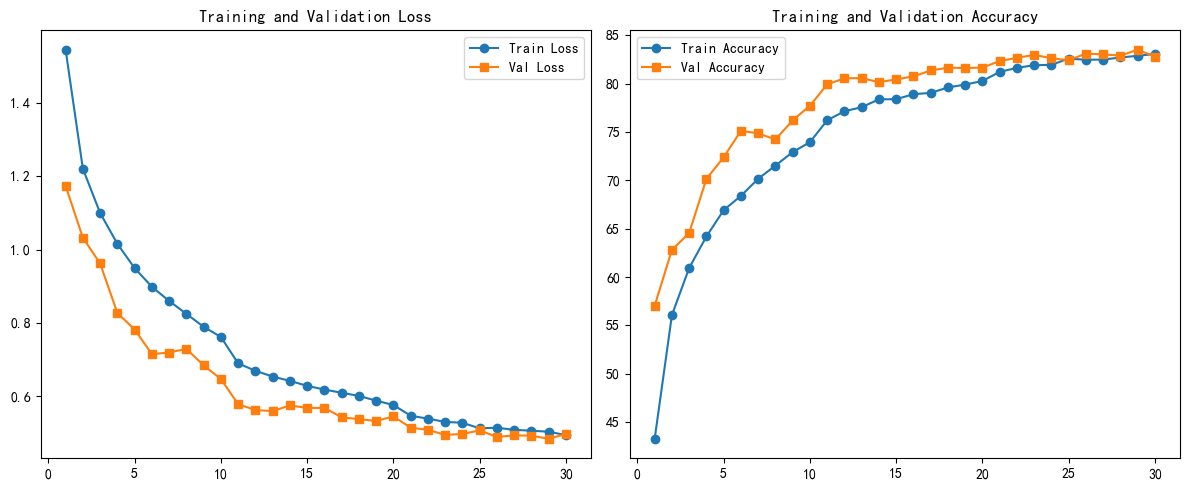

In [5]:
# 保存权重
save_path = os.path.join(RESULT_DIR, 'simple_cnn_cifar10.pth')
torch.save(model.state_dict(), save_path)
print(f"模型权重已保存至: {save_path}")

# 绘制学习曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(range(1, EPOCHS+1), history['train_loss'], label='Train Loss', marker='o')
ax1.plot(range(1, EPOCHS+1), history['val_loss'], label='Val Loss', marker='s')
ax1.set_title('Training and Validation Loss')
ax1.legend()

ax2.plot(range(1, EPOCHS+1), history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(range(1, EPOCHS+1), history['val_acc'], label='Val Accuracy', marker='s')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULT_DIR, 'exp3_cnn_learning_curves.png'))
plt.show()